# 04 — Statistics
Reporting over evaluation + version-selection output.


## Imports & Configuration
Libraries, config.py values, document-section page ranges.


In [2]:
# OUTPUTS: stats/figures/*.png, stats/*.csv, stats/*.md  (local and/or Drive per config.SAVE_MODE, folder name "stats")

%matplotlib inline
import re
import csv
import io
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openai
import tabulate  

from config import (
    LOCAL_ALMANAC_ROOT,
    CLEAN_PAGES_DIR, EVAL_OUTPUT_DIR, STATS_DIR, SAVE_MODE, LLM_LOG_DIR,
    OPENAI_KEY_FILE,
    DRIVE_ROOT_FOLDER, DRIVE_EVALUATION_FOLDER, DRIVE_CLEAN_PAGES_FOLDER,
    DRIVE_STATS4_FOLDER, DRIVE_LLM_LOG_FOLDER,
)

CLEAN_PAGES = Path(CLEAN_PAGES_DIR)
LLM_LOG     = Path(LLM_LOG_DIR)
EVAL_DIR    = Path(EVAL_OUTPUT_DIR)
STATS_OUT   = Path(STATS_DIR)
STATS_OUT.mkdir(exist_ok=True, parents=True)
FIG_DIR     = STATS_OUT / "figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)

GT_RECONCILED_DETAIL  = Path(LOCAL_ALMANAC_ROOT) / "score_vs_llm_ground_truth_detail.csv"
GT_RECONCILED_SUMMARY = Path(LOCAL_ALMANAC_ROOT) / "score_vs_llm_ground_truth_summary.csv"

DOCUMENT_SECTIONS = {
    "cover_ads":       list(range(1,   14)),
    "index":           list(range(14,  36)),
    "religious":       list(range(36,  38)) + list(range(86, 98)),
    "government":      list(range(38,  86)),
    "professionisti":  list(range(108, 129)),
    "industria":       list(range(132, 319)),
    "indice_generale": list(range(332, 488)),
    "provincia":       list(range(494, 571)),
}
GROUND_TRUTH_PAGES = [10, 14, 36, 42, 45, 58, 60, 63, 86, 87, 103, 110, 151, 167]


## Drive helpers
Drive auth, folder resolution, and the clean_pages/ file-ID index.


In [5]:
# Drive helpers (cached connection)

from drive_utils import get_drive_service, find_folder, list_files_in_folder, download_text, upload_bytes, get_or_create_folder, save_or_upload_csv, save_or_upload_text, find_latest_folder_local, find_latest_folder_drive, drive_file_exists

_stats4_root_id   = find_folder(get_drive_service(), DRIVE_ROOT_FOLDER)
stats4_folder_id  = get_or_create_folder(get_drive_service(), DRIVE_STATS4_FOLDER, _stats4_root_id)


# Walks a list of folder names down to a Drive folder ID.
def _resolve_drive_folder(drive_parts):
    service = get_drive_service()
    folder_id = find_folder(service, DRIVE_ROOT_FOLDER)
    for part in drive_parts:
        if folder_id is None:
            return None
        folder_id = find_folder(service, part, folder_id)
    return folder_id


def read_text_local_or_drive(local_path: Path, drive_parts: list):
    # local_path first, else drive_parts = folder path from root + filename
    if local_path.exists():
        try:
            return local_path.read_text(encoding="utf-8")
        except OSError as e:
            print(f"  WARNING: local file unreadable ({local_path}): {e} — falling back to Drive.")
    folder_id = _resolve_drive_folder(drive_parts[:-1])
    if folder_id is None:
        return None
    service = get_drive_service()
    file_id = drive_file_exists(service, folder_id, drive_parts[-1])
    return download_text(service, file_id) if file_id else None


# CLEAN PAGES DRIVE INDEX
# Resolves all clean_pages/page_X/ file IDs in one pass instead of 4 calls per file. Used throughout the score-only sections below.

_clean_pages_index = None  # {page_num: {filename: file_id}}

def build_clean_pages_index():
    # indexes clean_pages/ page_X subfolders on Drive once, falls back to local
    global _clean_pages_index
    if _clean_pages_index is not None:
        return _clean_pages_index

    if CLEAN_PAGES.exists():
        local_page_dirs = [
            d for d in CLEAN_PAGES.iterdir()
            if d.is_dir() and re.match(r'^page_\d+$', d.name)
        ]
        if local_page_dirs:
            _clean_pages_index = {}  # signal: use local reads directly
            return _clean_pages_index

    print("  Building Drive clean_pages index (one-time, ~1-2 min) ...")
    service = get_drive_service()
    root_id = find_folder(service, DRIVE_ROOT_FOLDER)
    if root_id is None:
        _clean_pages_index = {}
        return _clean_pages_index

    cp_folder_id = find_folder(service, DRIVE_CLEAN_PAGES_FOLDER, root_id)
    if cp_folder_id is None:
        _clean_pages_index = {}
        return _clean_pages_index

    subfolders = [
        f for f in list_files_in_folder(service, cp_folder_id)
        if f["mimeType"] == "application/vnd.google-apps.folder"
        and re.match(r'^page_\d+$', f["name"])
    ]

    index = {}
    for folder in subfolders:
        m = re.search(r'(\d+)', folder["name"])
        if not m:
            continue
        page_num = int(m.group(1))
        files = list_files_in_folder(service, folder["id"])
        index[page_num] = {f["name"]: f["id"] for f in files}

    _clean_pages_index = index
    print(f"  Index built: {len(index)} page folders cached.")
    return index


def read_clean_page_file(page_num, filename):
    # reads clean_pages/page_X/file: local, then cached Drive index, then direct Drive lookup
    local_path = CLEAN_PAGES / f"page_{page_num}" / filename
    if local_path.exists():
        try:
            return local_path.read_text(encoding="utf-8")
        except OSError as e:
            print(f"  WARNING: local file unreadable for page {page_num} "
                  f"({filename}): {e} — falling back to Drive.")

    index = build_clean_pages_index()

    if index:
        page_files = index.get(page_num, {})
        file_id = page_files.get(filename)
        if file_id is None:
            return None
        return download_text(get_drive_service(), file_id)

    return read_text_local_or_drive(
        local_path,
        [DRIVE_CLEAN_PAGES_FOLDER, f"page_{page_num}", filename]
    )


def find_latest_eval_source():
    # latest eval results/summary dfs, local first then Drive
    best_local = find_latest_folder_local(EVAL_DIR, "eval_all_")
    if best_local is not None:
        results_df = pd.read_csv(next(best_local.glob("*_results.csv")))
        summary_df = pd.read_csv(next(best_local.glob("*_page_summary.csv")))
        return results_df, summary_df, f"local:{best_local.name}"

    eval_folder_id = _resolve_drive_folder([DRIVE_EVALUATION_FOLDER])
    service = get_drive_service()
    best_drive = find_latest_folder_drive(service, eval_folder_id, "eval_all_")
    if best_drive is None:
        raise FileNotFoundError("No eval_all_ folder found locally or on Drive.")
    run_files = list_files_in_folder(service, best_drive["id"])
    results_f = next(f for f in run_files if f["name"].endswith("_results.csv"))
    summary_f = next(f for f in run_files if f["name"].endswith("_page_summary.csv"))
    results_df = pd.read_csv(io.StringIO(download_text(service, results_f["id"])))
    summary_df = pd.read_csv(io.StringIO(download_text(service, summary_f["id"])))
    return results_df, summary_df, f"drive:{best_drive['name']}"


/Users/charlottegarcia/global_venv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.2.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


## Shared helpers & eval data
General utilities, page classification, and the eval load that everything below scores against.


In [6]:
# Shared helpers & eval data

def get_section(page_num):
    for name, pages in DOCUMENT_SECTIONS.items():
        if page_num in pages:
            return name
    return "other"


# Pulls the missing-address percentage out of a propagation note.
def extract_missing_pct(note):
    if pd.isna(note) or not note:
        return 0.0
    m = re.search(r'\((\d+)%\)', str(note))
    return float(m.group(1)) if m else 0.0


# Saves a matplotlib figure locally and/or uploads it to Drive.
def save_fig(fig, name, version=None):
    prefix = f"{version}_" if version is not None else ""
    filename = f"{prefix}{name}.png"
    path = FIG_DIR / filename
    if SAVE_MODE in ("local", "both"):
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"  Figure saved: {path}")
    if SAVE_MODE in ("drive", "both") and stats4_folder_id:
        buf = io.BytesIO()
        fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
        upload_bytes(get_drive_service(), buf.getvalue(), filename, "image/png", stats4_folder_id)
        print(f"  ↑ {filename} uploaded to Drive")
    plt.show()
    plt.close(fig)


# ── Page-category classification (used by the score-only layout/ad-type section below). 
# SKIP_PAGES / PROVINCIA / the hardcoded AD_ONLY_RANGES override all short-circuit before layout detection ever runs, and SIMPLE_LAYOUT pages get NO_AD automatically (no ad-detection call at all).
AD_ONLY_RANGES = [
    (3, 5), (11, 13), (20, 21), (23, 23), (27, 27), (30, 31), (40, 41),
    (46, 47), (105, 107), (129, 131), (319, 331), (572, 575),
]
# Checks the page number against hardcoded full-ad ranges.
def is_full_ad_page(page_num):
    return any(lo <= page_num <= hi for lo, hi in AD_ONLY_RANGES)

SKIP_PAGES = {1, 2, 6, 7, 8, 9, 490, 571}
PROVINCIA_PAGES = set(DOCUMENT_SECTIONS["provincia"])

# Cover pages and negligible/blank pages have a real winner_filename 
EXCLUDE_FROM_CORPUS = {1, 6, 8, 9, 161, 170}

# Pages 44 and 263: the winning run's Ad Type wasn't captured by the standard eval on any candidate run consistently
MANUAL_LIVE_RECALL_OVERRIDE = {
    44:  "SIMPLE_LAYOUT (auto NO_AD)",
    263: "COMPLEX_LAYOUT: OTHER_UNPARSED",
}

_layout_ad_fallback = {}  # populated below once semantic_df exists


# Collapses ad-type label variants to one form.
def normalize_ad_type(val):
    if pd.isna(val):
        return None
    v = str(val).strip()
    if v == "FULL_AD":
        return "FULL_AD"
    if v.startswith("PARTIAL_AD"):
        return "PARTIAL_AD"
    if v.startswith("NO_AD"):
        return "NO_AD"
    return "OTHER_UNPARSED"  # unparseable LLM response — kept distinct, not bucketed


# Maps a page number to its almanac section.
def page_category(row):
    page_num = int(row["page_num"])
    if page_num in EXCLUDE_FROM_CORPUS:
        return "EXCLUDED (cover/negligible)"
    if page_num in MANUAL_LIVE_RECALL_OVERRIDE:
        return MANUAL_LIVE_RECALL_OVERRIDE[page_num]
    if is_full_ad_page(page_num):
        return "FULL_AD (hardcoded)"
    if page_num in PROVINCIA_PAGES:
        return "PROVINCIA"
    if page_num in SKIP_PAGES:
        return "SKIP_PAGES (real content)"
    layout, ad_type = row["Layout"], row["Ad Type"]
    if pd.isna(layout) or pd.isna(ad_type):
        fb_layout, fb_ad = _layout_ad_fallback.get(page_num, (None, None))
        if pd.isna(layout):
            layout = fb_layout
        if pd.isna(ad_type):
            ad_type = fb_ad
    if layout == "SIMPLE_LAYOUT":
        return "SIMPLE_LAYOUT (auto NO_AD)"
    if layout == "COMPLEX_LAYOUT":
        ad = normalize_ad_type(ad_type)
        return f"COMPLEX_LAYOUT: {ad}"
    return "UNCLASSIFIED"


# LOAD EVAL DATA (shared — both methods score against this)

results_df, summary_df, eval_source = find_latest_eval_source()
print(f"Using eval: {eval_source}")

semantic_df = results_df[results_df["Run"].str.contains("semantic", na=False)].copy()
semantic_df["page_num"] = semantic_df["Page"].apply(
    lambda x: int(re.search(r"(\d+)", str(x)).group(1)) if re.search(r"(\d+)", str(x)) else 0
)
semantic_df["section"]          = semantic_df["page_num"].apply(get_section)
semantic_df["missing_addr_pct"] = semantic_df["Propagation Note"].apply(extract_missing_pct)

# Fallback source for page_category(): first non-null Layout/Ad Type among ANY candidate run of a page for cases where the winning run's own eval row is missing one 
for _pn, _grp in semantic_df.groupby("page_num"):
    _layout_vals = _grp["Layout"].dropna()
    _ad_vals     = _grp["Ad Type"].dropna()
    _layout_ad_fallback[_pn] = (
        _layout_vals.iloc[0] if not _layout_vals.empty else None,
        _ad_vals.iloc[0] if not _ad_vals.empty else None,
    )

# Version number for this run — all figures and summary files share this N
def get_next_version_number(base_dir, base_name, ext):
    n = 1
    while (base_dir / f"{base_name}_{n}.{ext}").exists():
        n += 1
    return n

STATS_VERSION = get_next_version_number(CLEAN_PAGES, "statistics_summary", "md")
print(f"This run: statistics_summary_{STATS_VERSION}.md / figures/{STATS_VERSION}_XX.png")


Using eval: local:eval_all_20260629_1447_merged
This run: statistics_summary_1.md / figures/1_XX.png


## Old — LLM-arbitration stats
Old selection method, kept for the before/after comparison.


=== LLM-arbitration: selection tier & score distribution ===
Selection log: 571 pages
  with a winner_filename: 569
Resolved 563 winner rows to an eval row (6 pages skipped by evaluation, e.g. SKIP_PAGES)
  NOTE: 2 pages with no winner (tier=['FAILED']): ['page_510', 'provincia']

Selection tier distribution:
 selection_tier
TIER2     466
SINGLE     86
TIER1      10
FAILED      9
Name: count, dtype: int64
  Figure saved: stats/figures/1_02_tier_and_score_distribution_llm.png
  ↑ 1_02_tier_and_score_distribution_llm.png uploaded to Drive


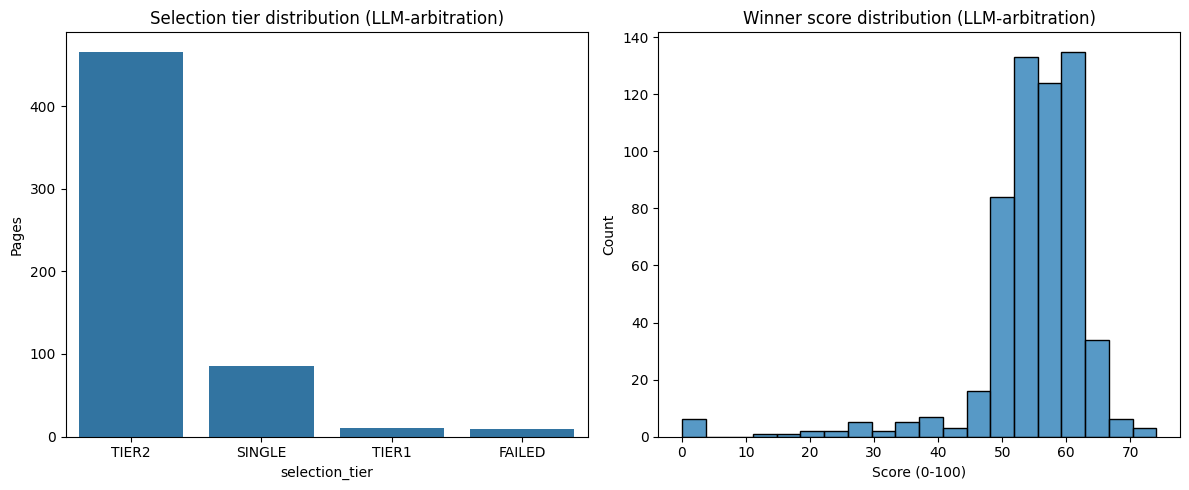


=== LLM-arbitration: ground-truth aggregate metrics ===
                           mean  median
metric                                 
char_accuracy         84.850000  94.750
bow_similarity        63.653571  72.730
semantic_precision    56.262857  59.850
semantic_recall       53.312857  57.555
semantic_f1           54.110000  56.595
row_count_similarity  92.330000  97.900


In [ ]:
# LLM-ARBITRATION (old method) — selection tier/score distribution + ground-truth aggregate metrics.
# Reads clean_pages_llm/selection_log.csv — the LLM-arbitration selector's own output, kept only for the "Selection Method Comparison" section.
print("=== LLM-arbitration: selection tier & score distribution ===")

llm_selection_text = read_text_local_or_drive(
    LLM_LOG / "selection_log.csv",
    [DRIVE_LLM_LOG_FOLDER, "selection_log.csv"]
)
llm_selection_df = pd.read_csv(io.StringIO(llm_selection_text))
print(f"Selection log: {len(llm_selection_df)} pages")

llm_resolved_df = llm_selection_df[llm_selection_df["winner_filename"].notna()].copy()
print(f"  with a winner_filename: {len(llm_resolved_df)}")

llm_winner_rows = []
for _, w in llm_resolved_df.iterrows():
    match = semantic_df[
        (semantic_df["Page"] == w["page"]) &
        (semantic_df["Run"] == w["winner_filename"])
    ]
    if not match.empty:
        r = match.iloc[0].to_dict()
        r["selection_tier"] = w["selection_tier"]
        r["confidence"]     = w["confidence"]
        r["winner_score"]   = w["winner_score"]
        r["all_scores"]     = w["all_scores"]
        llm_winner_rows.append(r)

llm_clean_df = pd.DataFrame(llm_winner_rows)
print(f"Resolved {len(llm_clean_df)} winner rows to an eval row "
      f"({len(llm_resolved_df) - len(llm_clean_df)} pages skipped by evaluation, e.g. SKIP_PAGES)")

llm_failed = llm_selection_df[llm_selection_df["winner_filename"].isna()]
if not llm_failed.empty:
    print(f"  NOTE: {len(llm_failed)} pages with no winner "
          f"(tier={llm_failed['selection_tier'].unique().tolist()}): "
          f"{llm_failed['page'].tolist()}")

llm_tier_counts = llm_selection_df["selection_tier"].value_counts()
print("\nSelection tier distribution:\n", llm_tier_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=llm_tier_counts.index, y=llm_tier_counts.values, ax=axes[0])
axes[0].set_title("Selection tier distribution (LLM-arbitration)")
axes[0].set_ylabel("Pages")

sns.histplot(llm_selection_df["winner_score"].dropna(), bins=20, ax=axes[1])
axes[1].set_title("Winner score distribution (LLM-arbitration)")
axes[1].set_xlabel("Score (0-100)")
plt.tight_layout()
save_fig(fig, "02_tier_and_score_distribution_llm", version=STATS_VERSION)


# ---- ground-truth aggregate (feeds tab:gt_aggregate's LLM-arbitration column) ----
print("\n=== LLM-arbitration: ground-truth aggregate metrics ===")

if GT_RECONCILED_SUMMARY.exists():
    llm_gt_summary = pd.read_csv(GT_RECONCILED_SUMMARY).set_index("metric")[
        ["llm_arbitration_mean", "llm_arbitration_median"]
    ]
    llm_gt_merged = llm_resolved_df.merge(
        semantic_df[["Page", "Run", "row_count_similarity", "semantic_f1"]],
        left_on=["page", "winner_filename"], right_on=["Page", "Run"], how="left",
    )
    llm_gt_rowcount = llm_gt_merged[
        llm_gt_merged["page_num"].isin(GROUND_TRUTH_PAGES) &
        llm_gt_merged["semantic_f1"].notna() & (llm_gt_merged["semantic_f1"] > 0)
    ]["row_count_similarity"]

    llm_gt_agg = llm_gt_summary.copy()
    llm_gt_agg.loc["row_count_similarity"] = [
        round(llm_gt_rowcount.mean(), 2), round(llm_gt_rowcount.median(), 2)
    ]
    llm_gt_agg = llm_gt_agg.rename(
        columns={"llm_arbitration_mean": "mean", "llm_arbitration_median": "median"}
    )
    print(llm_gt_agg)

    save_or_upload_csv(
        llm_gt_agg.reset_index(), STATS_OUT / f"{STATS_VERSION}_gt_aggregate_llm.csv",
        get_drive_service(), stats4_folder_id,
    )
else:
    print(f"  {GT_RECONCILED_SUMMARY} not found — skipping.")


## Score-only vs LLM-arbitration agreement


=== Score-only vs LLM-arbitration: winner agreement (full corpus, n=570) ===
  Pages compared: 570
  Agree: 178 (31.2%)
  Meaningful disagreement (not tied): 167
  Tied disagreement: 225
  Mean score gap (meaningful disagreements): 21.86
  Figure saved: stats/figures/1_03c_score_vs_llm_agreement.png
  ↑ 1_03c_score_vs_llm_agreement.png uploaded to Drive


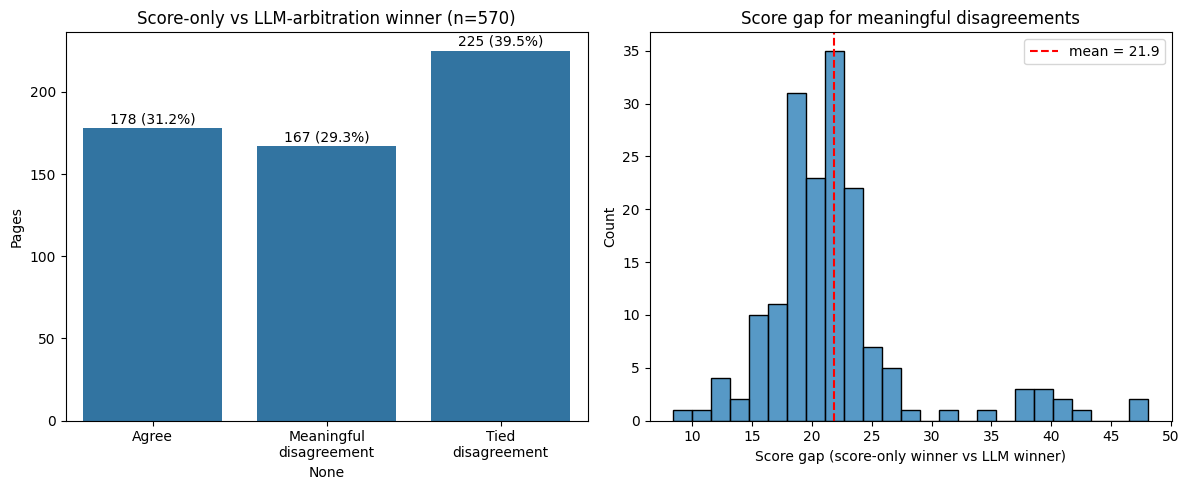


=== Score-only vs LLM-arbitration: winner agreement (ground truth, n=14) ===
  Agree: 3/14 — ['page_36', 'page_60', 'page_87']
  Disagree: 11/14 — ['page_10', 'page_103', 'page_110', 'page_14', 'page_151', 'page_167', 'page_42', 'page_45', 'page_58', 'page_63', 'page_86']


In [6]:
# SCORE-ONLY vs LLM-ARBITRATION — winner agreement
#
# Two comparisons, at two different scales 
#   1. Full corpus (570 pages): clean_pages/score_vs_llm_comparison.csv, real output of the score-only selector.
#   2. Ground-truth-only (14 pages): GT_RECONCILED_DETAIL, the reconciled comparison.

print("=== Score-only vs LLM-arbitration: winner agreement (full corpus, n=570) ===")

svl_text = read_text_local_or_drive(
    CLEAN_PAGES / "score_vs_llm_comparison.csv",
    [DRIVE_CLEAN_PAGES_FOLDER, "score_vs_llm_comparison.csv"]
)

if svl_text is None:
    print("  score_vs_llm_comparison.csv not found locally or on Drive — skipping.")
else:
    svl_df = pd.read_csv(io.StringIO(svl_text))

    n_svl        = len(svl_df)
    n_agree      = int(svl_df["agree"].sum())
    disagree_df  = svl_df[~svl_df["agree"]]
    meaningful_df    = disagree_df[~disagree_df["scores_tied"]]
    tied_disagree_df = disagree_df[disagree_df["scores_tied"]]

    print(f"  Pages compared: {n_svl}")
    print(f"  Agree: {n_agree} ({100*n_agree/n_svl:.1f}%)")
    print(f"  Meaningful disagreement (not tied): {len(meaningful_df)}")
    print(f"  Tied disagreement: {len(tied_disagree_df)}")
    print(f"  Mean score gap (meaningful disagreements): {meaningful_df['score_gap'].mean():.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    breakdown = pd.Series({
        "Agree": n_agree,
        "Meaningful\ndisagreement": len(meaningful_df),
        "Tied\ndisagreement": len(tied_disagree_df),
    })
    sns.barplot(x=breakdown.index, y=breakdown.values, ax=axes[0])
    axes[0].set_title(f"Score-only vs LLM-arbitration winner (n={n_svl})")
    axes[0].set_ylabel("Pages")
    for i, v in enumerate(breakdown.values):
        axes[0].text(i, v + 3, f"{v} ({100*v/n_svl:.1f}%)", ha="center")

    sns.histplot(meaningful_df["score_gap"], bins=25, ax=axes[1])
    axes[1].axvline(meaningful_df["score_gap"].mean(), color="red", linestyle="--",
                     label=f"mean = {meaningful_df['score_gap'].mean():.1f}")
    axes[1].set_title("Score gap for meaningful disagreements")
    axes[1].set_xlabel("Score gap (score-only winner vs LLM winner)")
    axes[1].legend()

    plt.tight_layout()
    save_fig(fig, "03c_score_vs_llm_agreement", version=STATS_VERSION)

    save_or_upload_csv(
        breakdown.rename("n_pages").reset_index().rename(columns={"index": "category"}),
        STATS_OUT / f"{STATS_VERSION}_score_vs_llm_agreement_breakdown.csv",
        get_drive_service(), stats4_folder_id,
    )

print("\n=== Score-only vs LLM-arbitration: winner agreement (ground truth, n=14) ===")

if GT_RECONCILED_DETAIL.exists():
    gt_det = pd.read_csv(GT_RECONCILED_DETAIL)
    gt_det["agree"] = gt_det["score_winner"] == gt_det["llm_winner"]
    n_gt_agree = int(gt_det["agree"].sum())
    print(f"  Agree: {n_gt_agree}/{len(gt_det)} — {gt_det[gt_det['agree']]['page'].tolist()}")
    print(f"  Disagree: {len(gt_det) - n_gt_agree}/{len(gt_det)} — "
          f"{gt_det[~gt_det['agree']]['page'].tolist()}")
else:
    print(f"  {GT_RECONCILED_DETAIL} not found — skipping.")


## Score-only method 
Source for the evaluation chapter: layout/ad-type, column fill rate, schema diversity, ground-truth metrics, provincia, final summary.


=== Score-only: selection method & score distribution ===
Selection log: 570 pages
  with a winner_filename: 570

Selection method distribution:
 selection_method
SCORE_TIED_RECENCY    305
SCORE_CLEAR           258
SINGLE                  6
EXCLUDED_FALLBACK       1
Name: count, dtype: int64
  Figure saved: stats/figures/1_09_score_method_and_score_distribution.png
  ↑ 1_09_score_method_and_score_distribution.png uploaded to Drive


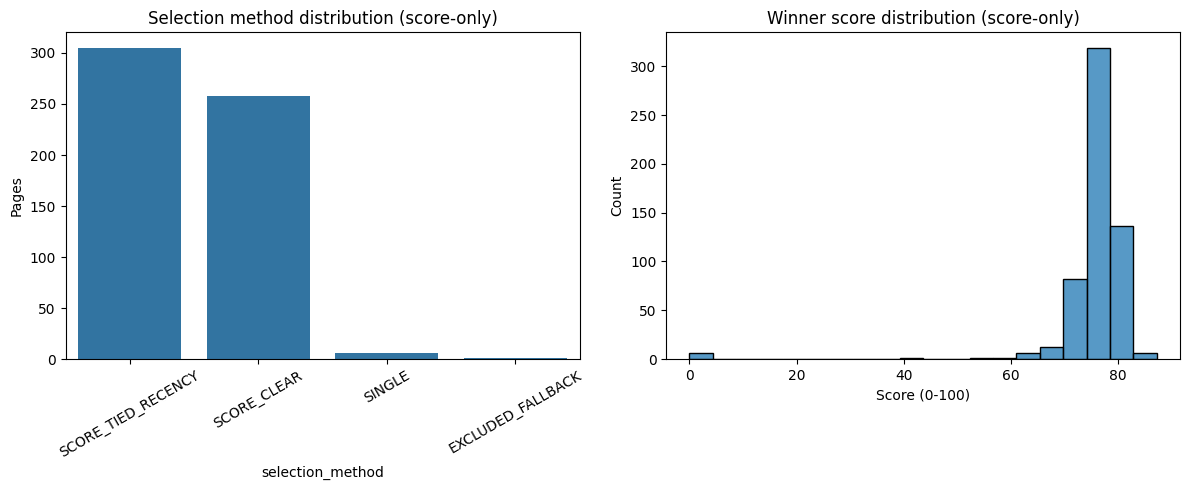

In [7]:
# SCORE-ONLY METHOD 
# Reads clean_pages/score_selection_log.csv d
print("=== Score-only: selection method & score distribution ===")

score_text = read_text_local_or_drive(
    CLEAN_PAGES / "score_selection_log.csv",
    [DRIVE_CLEAN_PAGES_FOLDER, "score_selection_log.csv"]
)
score_selection_df = pd.read_csv(io.StringIO(score_text))
print(f"Selection log: {len(score_selection_df)} pages")

score_resolved_df = score_selection_df[score_selection_df["winner_filename"].notna()].copy()
print(f"  with a winner_filename: {len(score_resolved_df)}")

score_failed = score_selection_df[score_selection_df["winner_filename"].isna()]
if not score_failed.empty:
    print(f"  NOTE: {len(score_failed)} pages with no winner "
          f"(method={score_failed['selection_method'].unique().tolist()}): "
          f"{score_failed['page'].tolist()}")

method_counts = score_resolved_df["selection_method"].value_counts()
print("\nSelection method distribution:\n", method_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(x=method_counts.index, y=method_counts.values, ax=axes[0])
axes[0].set_title("Selection method distribution (score-only)")
axes[0].set_ylabel("Pages")
axes[0].tick_params(axis='x', rotation=30)

sns.histplot(score_resolved_df["winner_score"].dropna(), bins=20, ax=axes[1])
axes[1].set_title("Winner score distribution (score-only)")
axes[1].set_xlabel("Score (0-100)")
plt.tight_layout()
save_fig(fig, "09_score_method_and_score_distribution", version=STATS_VERSION)


=== Score-only: layout/ad-type breakdown ===
Page categories (n=564):
  COMPLEX_LAYOUT: PARTIAL_AD: 281 (49.8%)
  PROVINCIA: 77 (13.7%)
  SIMPLE_LAYOUT (auto NO_AD): 75 (13.3%)
  COMPLEX_LAYOUT: NO_AD: 63 (11.2%)
  FULL_AD (hardcoded): 38 (6.7%)
  COMPLEX_LAYOUT: OTHER_UNPARSED: 28 (5.0%)
  SKIP_PAGES (real content): 2 (0.4%)
  Figure saved: stats/figures/1_04_layout_ad_type_clean.png
  ↑ 1_04_layout_ad_type_clean.png uploaded to Drive


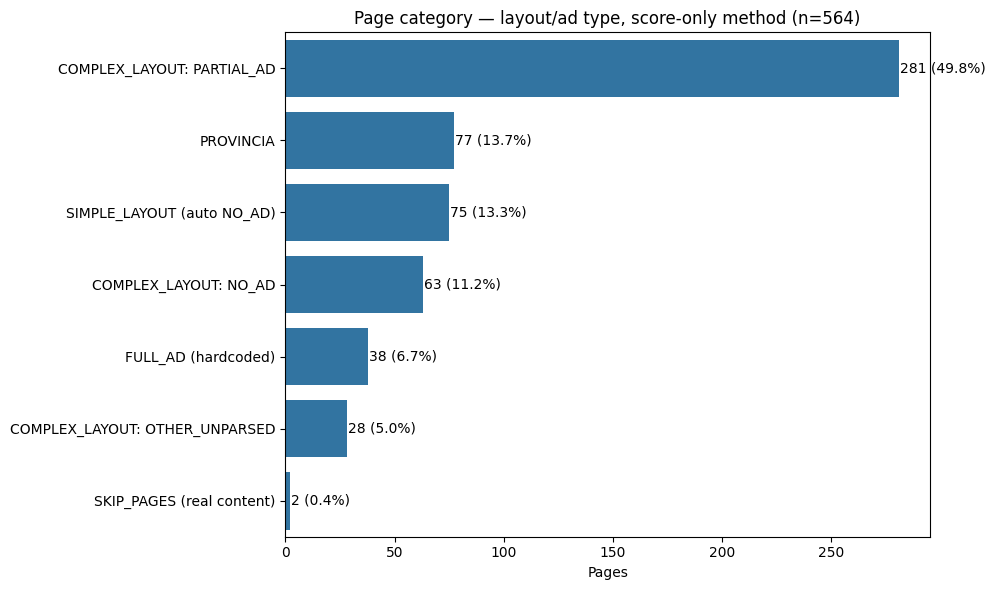

In [8]:
# SCORE-ONLY: layout / ad-type breakdown (feeds tab:layout_ad_type)

print("=== Score-only: layout/ad-type breakdown ===")

score_layout_ad_df = score_resolved_df.merge(
    semantic_df[["Page", "Run", "Layout", "Ad Type"]],
    left_on=["page", "winner_filename"], right_on=["Page", "Run"], how="left",
)
score_layout_ad_df["category"] = score_layout_ad_df.apply(page_category, axis=1)

score_resolved_df["layout_type"] = score_layout_ad_df["Layout"].values
score_resolved_df["ad_type"]     = score_layout_ad_df["Ad Type"].apply(normalize_ad_type).values
score_resolved_df["category"]    = score_layout_ad_df["category"].values

# The 564-page content corpus excludes cover/negligible pages (see EXCLUDE_FROM_CORPUS in cell 1) — drop them before counting/plotting
score_corpus_df = score_resolved_df[score_resolved_df["category"] != "EXCLUDED (cover/negligible)"]

score_category_counts = score_corpus_df["category"].value_counts()
n_score_total = len(score_corpus_df)

print(f"Page categories (n={n_score_total}):")
for cat, c in score_category_counts.items():
    print(f"  {cat}: {c} ({100*c/n_score_total:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 6))
cat_order = score_category_counts.index.tolist()
sns.barplot(x=score_category_counts.values, y=cat_order, ax=ax)
ax.set_title(f"Page category — layout/ad type, score-only method (n={n_score_total})")
ax.set_xlabel("Pages")
for i, v in enumerate(score_category_counts.values):
    ax.text(v + 0.5, i, f"{v} ({100*v/n_score_total:.1f}%)", va="center")
plt.tight_layout()
save_fig(fig, "04_layout_ad_type_clean", version=STATS_VERSION)

save_or_upload_csv(
    score_corpus_df[["page", "page_num", "winner_filename", "selection_method",
                      "winner_score", "layout_type", "ad_type", "category"]],
    STATS_OUT / f"{STATS_VERSION}_layout_ad_type_by_page_score.csv",
    get_drive_service(), stats4_folder_id,
)


=== Score-only: column fill rates ===
                 fill_Name  fill_Address  fill_Location  fill_Category  \
section                                                                  
cover_ads             0.97          0.82           0.03           0.88   
government            0.93          0.96           0.55           1.00   
index                 1.00          0.77           0.86           1.00   
indice_generale       1.00          1.00           0.68           1.00   
industria             0.99          1.00           0.53           1.00   
other                 0.94          0.77           0.61           0.98   
professionisti        1.00          1.00           0.56            NaN   
provincia             0.99          0.14            NaN            NaN   
religious             0.99          0.98           0.85            NaN   

                 fill_Profession  fill_Additional Info  
section                                                 
cover_ads                   0.19 

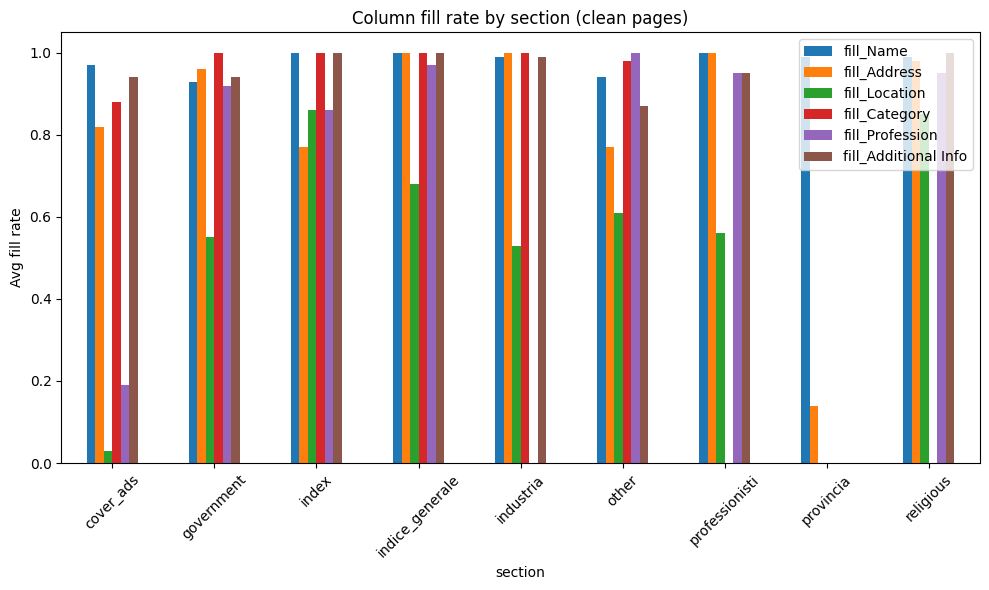

In [9]:
# SCORE-ONLY: column fill rate by section (feeds fig:column_fill_rates)

print("=== Score-only: column fill rates ===")

# Structural checks on one selected-run semantic CSV.
def analyze_clean_csv(page_num):
    text = read_clean_page_file(page_num, f"page_{page_num}_semantic.csv")
    if text is None:
        return None
    rows = list(csv.DictReader(io.StringIO(text)))
    rows = [r for r in rows if r.get("Name", "").strip() != "__SECTION__"]
    if not rows:
        return None
    header = list(rows[0].keys())
    fill = {
        col: sum(1 for r in rows if str(r.get(col, "") or "").strip()) / len(rows)
        for col in header
    }
    return {"n_rows": len(rows), "fill_rates": fill}


quality_records = []
for page_num in score_resolved_df["page_num"].unique():
    q = analyze_clean_csv(int(page_num))
    if q:
        rec = {"page_num": page_num, "n_rows": q["n_rows"], "section": get_section(int(page_num))}
        rec.update({f"fill_{k}": v for k, v in q["fill_rates"].items()})
        quality_records.append(rec)

quality_df = pd.DataFrame(quality_records)

if quality_df.empty:
    print("  WARNING: no clean page CSVs could be read — "
          "check that clean_pages/page_X/ folders exist locally or on Drive.")
    fill_by_section = pd.DataFrame()
else:
    common_cols = ["fill_Name", "fill_Address", "fill_Location",
                    "fill_Category", "fill_Profession", "fill_Additional Info"]
    present_cols = [c for c in common_cols if c in quality_df.columns]
    fill_by_section = quality_df.groupby("section")[present_cols].mean().round(2)
    print(fill_by_section)

    fig, ax = plt.subplots(figsize=(10, 6))
    fill_by_section.plot.bar(ax=ax)
    ax.set_title("Column fill rate by section (clean pages)")
    ax.set_ylabel("Avg fill rate")
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    save_fig(fig, "05_column_fill_rates_clean", version=STATS_VERSION)


In [10]:
# SCORE-ONLY: header / schema diversity 

print("=== Score-only: header / schema diversity ===")

header_counts = Counter()
page_headers  = {}
for page_num in score_resolved_df["page_num"].unique():
    page_num = int(page_num)
    if page_num in EXCLUDE_FROM_CORPUS:
        continue
    text = read_clean_page_file(page_num, f"page_{page_num}_semantic.csv")
    if text is None:
        print(f"  WARNING: page {page_num} (in the 564-page corpus) could not be "
              f"read -- excluded from header count")
        continue
    rows = list(csv.DictReader(io.StringIO(text)))
    if not rows:
        print(f"  WARNING: page {page_num} (in the 564-page corpus) has 0 data "
              f"rows -- excluded from header count")
        continue
    header = tuple(h.strip() for h in rows[0].keys())
    header_counts[header] += 1
    page_headers[page_num] = header

n_header_pages = len(page_headers)
if n_header_pages == 0:
    print("  WARNING: no clean page CSVs could be read for header analysis.")
else:
    n_distinct_headers = len(header_counts)
    modal_header, modal_count = header_counts.most_common(1)[0]
    modal_pct = 100 * modal_count / n_header_pages

    header_summary_df = pd.DataFrame(
        [{"header": " | ".join(h), "n_pages": c, "pct_of_pages": round(100 * c / n_header_pages, 1)}
         for h, c in header_counts.most_common()]
    )
    print(f"  Pages in corpus with a readable header: {n_header_pages}")
    print(f"  Distinct header signatures: {n_distinct_headers}")
    print(f"  Modal header covers {modal_count}/{n_header_pages} pages ({modal_pct:.1f}%)")
    print(header_summary_df.head(15))

    col_presence = Counter()
    for h in page_headers.values():
        for col in set(c.strip().lower() for c in h):
            col_presence[col] += 1
    col_presence_df = pd.DataFrame(
        [{"column": col, "n_pages": c, "pct_of_pages": round(100 * c / n_header_pages, 1)}
         for col, c in col_presence.most_common()]
    )
    print(col_presence_df)

    save_or_upload_csv(
        header_summary_df, STATS_OUT / f"{STATS_VERSION}_header_signatures.csv",
        get_drive_service(), stats4_folder_id,
    )
    save_or_upload_csv(
        col_presence_df, STATS_OUT / f"{STATS_VERSION}_column_presence.csv",
        get_drive_service(), stats4_folder_id,
    )


=== Score-only: header / schema diversity ===
  Pages in corpus with a readable header: 564
  Distinct header signatures: 26
  Modal header covers 179/564 pages (31.7%)
                                               header  n_pages  pct_of_pages
0   Name | Address | Location | Category | Additio...      179          31.7
1   Name | Address | Location | Category | Additio...      111          19.7
2   Provincia | Section | Role_or_Profession | Nam...       77          13.7
3   Name | Address | Location | Category | Additio...       42           7.4
4   Name | Address | Category | Additional Info | ...       36           6.4
5   Name | Address | Location | Role | Profession ...       32           5.7
6   Name | Address | Location | Role | Profession ...       14           2.5
7   Name | Address | Location | Profession | Addit...       13           2.3
8                                     Category | Page       10           1.8
9   Name | Address | Location | Category | Additio...        

=== Score-only: ground-truth aggregate metrics ===
  score_vs_llm_ground_truth_summary.csv not found — skipping.

=== Score-only: ground-truth metrics by page (tab:gt_metrics) ===
 page_num  char_accuracy  bow_similarity  row_count_similarity  semantic_precision  semantic_recall  semantic_f1  semantic_f1_col_aware  name_recall
       10          79.15           76.96                100.00               90.91            90.91        90.91                  90.91          NaN
       14          78.36           58.19                 98.08               63.29            78.12        69.93                   0.00          NaN
       36          98.20           87.86                100.00               40.96            38.20        39.53                  60.47       100.00
       42          96.30           77.26                 92.86               75.86            61.11        67.69                  55.38        84.62
       45          95.10           58.95                 97.62             

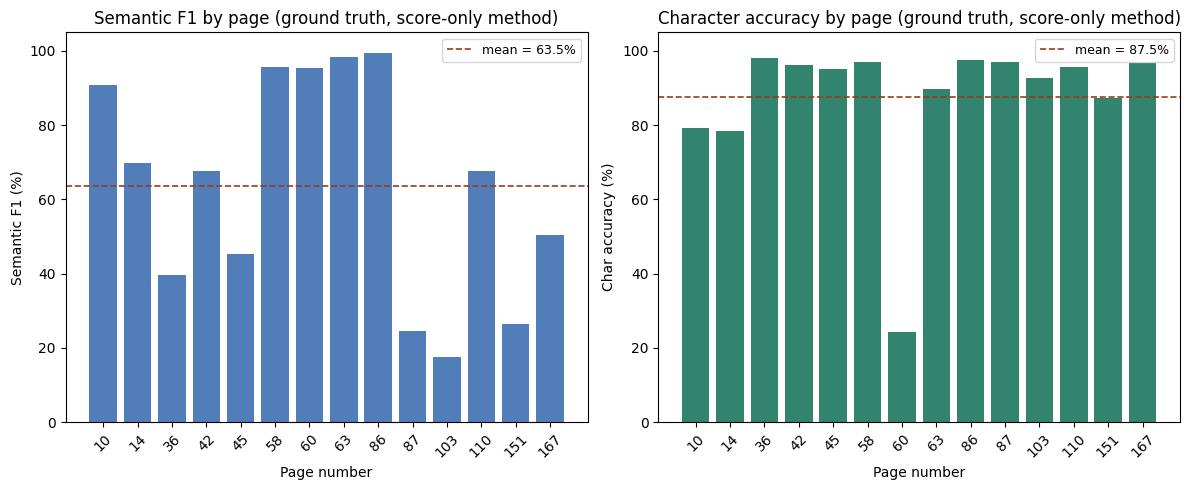

In [8]:
# SCORE-ONLY: ground-truth metrics — aggregate (tab:gt_aggregate) and per-page (tab:gt_metrics, fig:gt_quality_by_page).

print("=== Score-only: ground-truth aggregate metrics ===")

if GT_RECONCILED_SUMMARY.exists():
    score_gt_summary = pd.read_csv(GT_RECONCILED_SUMMARY).set_index("metric")[
        ["score_only_mean", "score_only_median"]
    ]
    score_gt_merged_rc = score_resolved_df.merge(
        semantic_df[["Page", "Run", "row_count_similarity", "semantic_f1"]],
        left_on=["page", "winner_filename"], right_on=["Page", "Run"], how="left",
    )
    score_gt_rowcount = score_gt_merged_rc[
        score_gt_merged_rc["page_num"].isin(GROUND_TRUTH_PAGES) &
        score_gt_merged_rc["semantic_f1"].notna() & (score_gt_merged_rc["semantic_f1"] > 0)
    ]["row_count_similarity"]

    score_gt_agg = score_gt_summary.copy()
    score_gt_agg.loc["row_count_similarity"] = [
        round(score_gt_rowcount.mean(), 2), round(score_gt_rowcount.median(), 2)
    ]
    score_gt_agg = score_gt_agg.rename(
        columns={"score_only_mean": "mean", "score_only_median": "median"}
    )
    print(score_gt_agg)

    save_or_upload_csv(
        score_gt_agg.reset_index(), STATS_OUT / f"{STATS_VERSION}_gt_aggregate_score.csv",
        get_drive_service(), stats4_folder_id,
    )
else:
    print(f"  {GT_RECONCILED_SUMMARY} not found — skipping.")


print("\n=== Score-only: ground-truth metrics by page (tab:gt_metrics) ===")

score_gt_df = score_resolved_df.merge(
    semantic_df[["Page", "Run", "char_accuracy", "bow_similarity", "row_count_similarity",
                 "semantic_precision", "semantic_recall", "semantic_f1",
                 "semantic_f1_col_aware", "name_recall"]],
    left_on=["page", "winner_filename"], right_on=["Page", "Run"], how="left",
)
score_gt_df = score_gt_df[
    score_gt_df["page_num"].isin(GROUND_TRUTH_PAGES) &
    score_gt_df["semantic_f1"].notna() &
    (score_gt_df["semantic_f1"] > 0)
].copy().sort_values("page_num")

if score_gt_df.empty:
    print("  No ground truth pages with F1 scores found.")
else:
    print(score_gt_df[["page_num", "char_accuracy", "bow_similarity", "row_count_similarity",
                        "semantic_precision", "semantic_recall", "semantic_f1",
                        "semantic_f1_col_aware", "name_recall"]].to_string(index=False))
    print(f"\n  Mean semantic F1:   {score_gt_df['semantic_f1'].mean():.1f}%")
    print(f"  Mean char accuracy: {score_gt_df['char_accuracy'].mean():.1f}%")

    save_or_upload_csv(
        score_gt_df[["page", "page_num", "char_accuracy", "bow_similarity", "row_count_similarity",
                      "semantic_precision", "semantic_recall", "semantic_f1",
                      "semantic_f1_col_aware", "name_recall"]],
        STATS_OUT / f"{STATS_VERSION}_gt_metrics_by_page_score.csv",
        get_drive_service(), stats4_folder_id,
    )

    page_labels = score_gt_df["page_num"].astype(int).astype(str).tolist()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(page_labels, score_gt_df["semantic_f1"], color="#3266ad", alpha=0.85)
    axes[0].axhline(score_gt_df["semantic_f1"].mean(), color="#993C1D", linestyle="--",
                    linewidth=1.2, label=f"mean = {score_gt_df['semantic_f1'].mean():.1f}%")
    axes[0].set_ylim(0, 105)
    axes[0].set_title("Semantic F1 by page (ground truth, score-only method)")
    axes[0].set_ylabel("Semantic F1 (%)")
    axes[0].set_xlabel("Page number")
    axes[0].legend(fontsize=9)
    axes[0].tick_params(axis="x", rotation=45)

    axes[1].bar(page_labels, score_gt_df["char_accuracy"], color="#0F6E56", alpha=0.85)
    axes[1].axhline(score_gt_df["char_accuracy"].mean(), color="#993C1D", linestyle="--",
                    linewidth=1.2, label=f"mean = {score_gt_df['char_accuracy'].mean():.1f}%")
    axes[1].set_ylim(0, 105)
    axes[1].set_title("Character accuracy by page (ground truth, score-only method)")
    axes[1].set_ylabel("Char accuracy (%)")
    axes[1].set_xlabel("Page number")
    axes[1].legend(fontsize=9)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    save_fig(fig, "05_gt_quality_by_page_clean", version=STATS_VERSION)


=== Provincia section statistics ===
  Town-info source: local:provincia_di_venezia_4.csv
  Ads source: local:provincia_ads_4.csv
  Provincia info rows (towns): 41
  Field fill rates: {'Frazioni': 0.95, 'Abitanti': 0.93, 'Superficie': 0.95, 'Stazione': 1.0, 'Prodotti': 0.93, 'Altre_info': 0.54}
  Provincia ads rows (raw): 83
  Address fill rate (raw): 92.77%
  Note: 19 rows have a numeric Category (leaked index, e.g. ['2288', '2288', ' 635']) -- excluded from the category chart below only, not from the row count or address fill rate above.
  Top categories (chart, numeric-category rows excluded): [('Macchine per scrivere', 9), ('Macchine per scrivere - Calcolatrici - Duplicatori', 2), ('Office Supplies', 2), ('Officina Riparazioni', 2), ('Repair', 2), ('Office Equipment', 2), ('Macchine per Scrivere', 2), ('Office Furniture', 2), ('Venezia', 2), ('Varie', 1)]
  Recurring-advertiser contamination (Category field): 33/83 (39.8%) -- 17 bare phone-number-fragment rows, 16 business-name-var

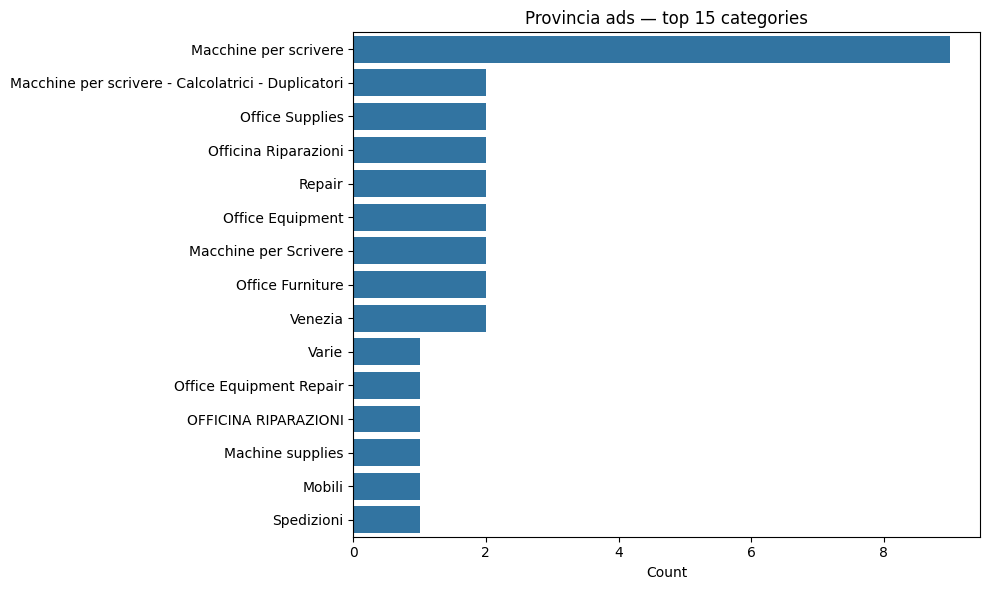

In [12]:
# SCORE-ONLY: provincia section statistics (feeds fig:provincia_categories)

print("=== Provincia section statistics ===")

def _find_latest_versioned(base_name, local_dir, drive_parts):
    # highest-numbered base_name_N.csv by suffix (not mtime), local first then Drive
    if local_dir.exists():
        local_matches = [
            p for p in local_dir.glob(f"{base_name}_*.csv")
            if re.search(r"_(\d+)\.csv$", p.name)
        ]
        if local_matches:
            local_matches.sort(key=lambda p: int(re.search(r"_(\d+)\.csv$", p.name).group(1)))
            newest = local_matches[-1]
            try:
                return newest.read_text(encoding="utf-8"), f"local:{newest.name}"
            except OSError as e:
                print(f"  WARNING: local read failed for {newest.name} ({e}) -- falling back to Drive.")

    folder_id = _resolve_drive_folder(drive_parts)
    if folder_id is None:
        return None, None
    service = get_drive_service()
    files = [f for f in list_files_in_folder(service, folder_id)
             if re.match(rf"^{re.escape(base_name)}_\d+\.csv$", f["name"])]
    if not files:
        return None, None
    files.sort(key=lambda f: int(re.search(r"_(\d+)\.csv$", f["name"]).group(1)))
    newest = files[-1]
    return download_text(service, newest["id"]), f"drive:{newest['name']}"

prov_info_text, prov_info_src = _find_latest_versioned(
    "provincia_di_venezia", CLEAN_PAGES, [DRIVE_CLEAN_PAGES_FOLDER]
)
prov_ads_text, prov_ads_src = _find_latest_versioned(
    "provincia_ads", CLEAN_PAGES, [DRIVE_CLEAN_PAGES_FOLDER]
)
print(f"  Town-info source: {prov_info_src}")
print(f"  Ads source: {prov_ads_src}")

def _read_csv_dedup_columns(text):
    reader = csv.reader(io.StringIO(text))
    raw_header = next(reader)
    header = [h.strip() for h in raw_header]
    rows = []
    for raw_row in reader:
        d = {}
        for col, val in zip(header, raw_row):
            val = (val or "").strip()
            d[col] = d.get(col) or val
        rows.append(d)
    return rows

if prov_info_text is not None:
    prov_info = _read_csv_dedup_columns(prov_info_text)
    print(f"  Provincia info rows (towns): {len(prov_info)}")
    info_cols = ["Frazioni", "Abitanti", "Superficie", "Stazione", "Prodotti", "Altre_info"]
    info_fill = {
        c: round(sum(1 for r in prov_info if r.get(c, "").strip()) / max(len(prov_info), 1), 2)
        for c in info_cols if prov_info and c in prov_info[0]
    }
    print("  Field fill rates:", info_fill)
else:
    prov_info = []

if prov_ads_text is not None:
    prov_ads = list(csv.DictReader(io.StringIO(prov_ads_text)))
    print(f"  Provincia ads rows (raw): {len(prov_ads)}")

    addr_filled = sum(1 for r in prov_ads if r.get("Address", "").strip())
    print(f"  Address fill rate (raw): {addr_filled/max(len(prov_ads),1):.2%}")

    bad = [r for r in prov_ads if r.get("Category", "").strip().isdigit()]
    if bad:
        print(f"  Note: {len(bad)} rows have a numeric Category (leaked index, "
              f"e.g. {[r['Category'] for r in bad[:3]]}) -- excluded from the "
              f"category chart below only, not from the row count or address "
              f"fill rate above.")
    prov_ads_for_chart = [r for r in prov_ads if not r.get("Category", "").strip().isdigit()]

    cat_counts = Counter(
        r.get("Category", "").strip() for r in prov_ads_for_chart if r.get("Category", "").strip()
    )
    print("  Top categories (chart, numeric-category rows excluded):", cat_counts.most_common(10))

    # ── Recurring-advertiser contamination check ───────────────────────
    # (Via XXII Marzo, tel. 2288, Macchine per scrivere" / typewriters, "2288" and OCR variants)
    RECURRING_AD_PATTERN = re.compile(r"2288|scrivere|typewriter|machine.{0,10}writ", re.I)
    recurring_matches = [
        r for r in prov_ads if RECURRING_AD_PATTERN.search(r.get("Category", "").strip())
    ]
    n_recurring = len(recurring_matches)
    n_phone = sum(1 for r in prov_ads if re.search(r"2288", r.get("Category", ""), re.I))
    n_name = sum(
        1 for r in prov_ads
        if re.search(r"scrivere|typewriter|machine.{0,10}writ", r.get("Category", ""), re.I)
    )
    print(f"  Recurring-advertiser contamination (Category field): "
          f"{n_recurring}/{len(prov_ads)} ({n_recurring/len(prov_ads):.1%}) "
          f"-- {n_phone} bare phone-number-fragment rows, {n_name} business-name-variant rows")

    if cat_counts:
        fig, ax = plt.subplots(figsize=(10, 6))
        cats, counts = zip(*cat_counts.most_common(15))
        sns.barplot(x=list(counts), y=list(cats), ax=ax)
        ax.set_title("Provincia ads — top 15 categories")
        ax.set_xlabel("Count")
        plt.tight_layout()
        save_fig(fig, "06_provincia_ad_categories", version=STATS_VERSION)
else:
    prov_ads = []
    addr_filled = 0


In [13]:
# FINAL — SAVE STATISTICS SUMMARY (score-only method, versioned MD + CSV)

stats_md_path  = STATS_OUT / f"statistics_summary_{STATS_VERSION}.md"
stats_csv_path = STATS_OUT / f"statistics_summary_{STATS_VERSION}.csv"

lines = [
    "# Venice Almanac — Statistics Summary (score-only / production method)",
    f"Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}",
    f"Eval source: {eval_source}",
    f"Stats version: {STATS_VERSION}",
    "",
    "---",
    "",
    "## Selection",
    f"- Total pages in log: {len(score_selection_df)}",
    f"- Pages with a winner filename: {len(score_resolved_df)}",
    "",
    "## Layout / Ad Type",
    "",
]
lines.append(score_category_counts.to_markdown() if not score_category_counts.empty else "_No data_")

lines += [
    "",
    "## Column Fill Rates",
    "",
]
lines.append(fill_by_section.to_markdown() if not fill_by_section.empty else "_No data_")

lines += [
    "",
    "## Ground Truth Metrics (by page)",
    "",
]
if not score_gt_df.empty:
    lines.append(
        score_gt_df[["page_num", "semantic_f1", "char_accuracy", "bow_similarity"]]
        .to_markdown(index=False)
    )
else:
    lines.append("_No ground truth pages found_")

lines += [
    "",
    "## Provincia",
    f"- Info rows (towns): {len(prov_info)}",
    f"- Ads rows: {len(prov_ads)}",
]
if prov_ads:
    lines.append(f"- Ads address fill rate: {addr_filled/max(len(prov_ads),1):.2%}")

save_or_upload_text("\n".join(lines), stats_md_path, get_drive_service(), stats4_folder_id)
print(f"Markdown summary saved: {stats_md_path}")

csv_rows = []
if not fill_by_section.empty:
    for section in fill_by_section.index:
        row = {"section": section}
        for col in fill_by_section.columns:
            row[col] = fill_by_section.loc[section, col]
        csv_rows.append(row)

stats_csv = pd.DataFrame(csv_rows)
save_or_upload_csv(stats_csv, stats_csv_path, get_drive_service(), stats4_folder_id)
print(f"CSV summary saved: {stats_csv_path}")

if not score_gt_df.empty:
    gt_csv_path = STATS_OUT / f"ground_truth_metrics_{STATS_VERSION}.csv"
    save_or_upload_csv(
        score_gt_df[["page_num", "semantic_f1", "char_accuracy",
                      "bow_similarity", "semantic_f1_col_aware", "name_recall"]],
        gt_csv_path, get_drive_service(), stats4_folder_id,
    )
    print(f"Ground truth metrics saved: {gt_csv_path}")

print(f"\nAll outputs for run {STATS_VERSION}:")
print(f"  {stats_md_path.name}")
print(f"  {stats_csv_path.name}")
print(f"  Figures: {STATS_VERSION}_04_... through {STATS_VERSION}_09_...")


Markdown summary saved: stats/statistics_summary_1.md
CSV summary saved: stats/statistics_summary_1.csv
Ground truth metrics saved: stats/ground_truth_metrics_1.csv

All outputs for run 1:
  statistics_summary_1.md
  statistics_summary_1.csv
  Figures: 1_04_... through 1_09_...


## LLM representativeness sample
Stratified sample, LLM-rated CSV faithfulness to OCR text.


=== LLM representativeness check (stratified sample) ===
  Sampled 45 pages across 9 sections
  [cover_ads] page 12: score=3
  [cover_ads] page 10: score=4
  [cover_ads] page 1: score=2
  [cover_ads] page 9: score=2
  [cover_ads] page 6: score=1
  [index] page 14: score=3
  [index] page 27: score=4
  [index] page 22: score=1
  [index] page 15: score=2
  [index] page 29: score=1
  [religious] page 93: score=2
  [religious] page 95: score=2
  [religious] page 36: score=3
  [religious] page 96: score=2
  [religious] page 89: score=3
  [government] page 65: score=2
  [government] page 78: score=2
  [government] page 64: score=2
  [government] page 81: score=2
  [government] page 62: score=3
  [other] page 321: score=5
  [other] page 325: score=4
  [other] page 491: score=2
  [other] page 489: score=3
  [other] page 106: score=3
  [professionisti] page 108: score=3
  [professionisti] page 125: score=4
  [professionisti] page 123: score=2
  [professionisti] page 109: score=3
  [professionist

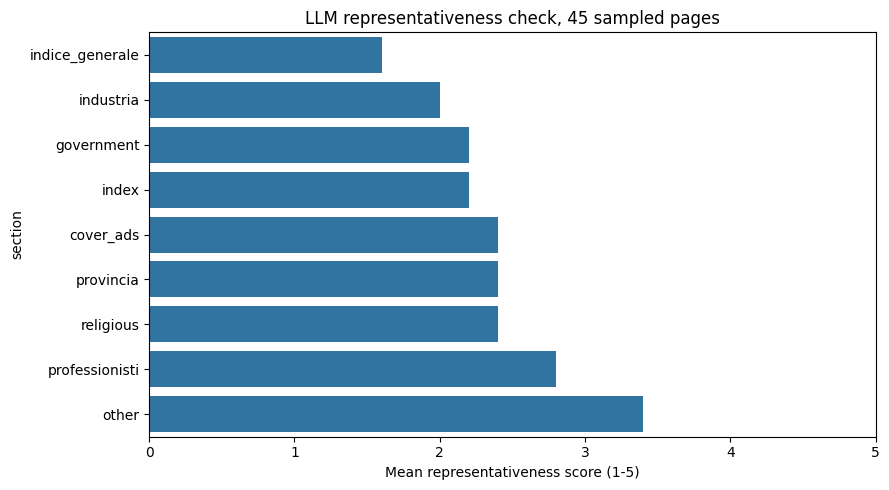


=== DONE ===
Figures saved to: stats/figures/


In [ ]:
# LLM REPRESENTATIVENESS SAMPLE (stratified, ~5/section)
# Samples up to 5 pages per DOCUMENT_SECTION from the score-only method's resolved pages, sends each page's (OCR text, winning CSV) to an LLM, and asks for a 1-5 representativeness score plus notes on missing/ hallucinated/structural errors.


print("=== LLM representativeness check (stratified sample) ===")

REPRESENTATIVENESS_SAMPLE_SIZE = 5
REPRESENTATIVENESS_SEED = 42

score_page_nums = score_resolved_df["page_num"].drop_duplicates().astype(int)
pages_by_section = {}
for pn in score_page_nums:
    pages_by_section.setdefault(get_section(pn), []).append(pn)

sampled_pages = []
for sect_name, pns in pages_by_section.items():
    s = pd.Series(pns)
    n = min(REPRESENTATIVENESS_SAMPLE_SIZE, len(s))
    for p in s.sample(n=n, random_state=REPRESENTATIVENESS_SEED):
        sampled_pages.append((sect_name, int(p)))

print(f"  Sampled {len(sampled_pages)} pages across {len(pages_by_section)} sections")

REPRESENTATIVENESS_PROMPT = """You are checking whether a structured CSV extraction faithfully represents the raw OCR text of a page from a 1947 Venetian commercial almanac.

RAW OCR TEXT:
{ocr_text}

EXTRACTED CSV:
{csv_text}

Rate how well the CSV represents the OCR text on a scale of 1-5:
5 = complete and accurate, nothing missing or invented
4 = minor omissions or errors, overall faithful
3 = noticeable gaps or errors, but the core content is there
2 = major omissions, hallucinated content, or structural errors
1 = the CSV bears little resemblance to the OCR text

Answer in exactly this format:
SCORE: <1-5>
NOTES: <one or two sentences on missing, hallucinated, or structurally wrong content, or "none" if score is 5>"""

with open(Path(OPENAI_KEY_FILE)) as f:
    _rep_key_params = dict(v.strip().split("=", 1) for v in f if "=" in v)
_rep_client = openai.OpenAI(api_key=_rep_key_params["api_key"])

rep_records = []
for sect_name, page_num in sampled_pages:
    ocr_text = read_clean_page_file(page_num, f"page_{page_num}_ocr.txt") or ""
    csv_text = read_clean_page_file(page_num, f"page_{page_num}_semantic.csv") or ""
    if not ocr_text or not csv_text:
        print(f"  [{sect_name}] page {page_num}: skipped, missing OCR or CSV text")
        continue

    prompt = REPRESENTATIVENESS_PROMPT.format(ocr_text=ocr_text[:6000], csv_text=csv_text[:6000])
    try:
        resp = _rep_client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0,
        )
        reply = resp.choices[0].message.content.strip()
    except Exception as e:
        print(f"  [{sect_name}] page {page_num}: API error — {e}")
        continue

    score_m = re.search(r"SCORE:\s*(\d)", reply)
    notes_m = re.search(r"NOTES:\s*(.*)", reply, re.DOTALL)
    score = int(score_m.group(1)) if score_m else None
    notes = notes_m.group(1).strip() if notes_m else reply

    print(f"  [{sect_name}] page {page_num}: score={score}")
    rep_records.append({
        "section": sect_name, "page_num": page_num,
        "score": score, "notes": notes,
    })

rep_df = pd.DataFrame(rep_records)

if not rep_df.empty:
    print("\nMean representativeness score by section:")
    print(rep_df.groupby("section")["score"].mean().round(2))

    fig, ax = plt.subplots(figsize=(9, 5))
    sect_means = rep_df.groupby("section")["score"].mean().sort_values()
    sns.barplot(x=sect_means.values, y=sect_means.index, ax=ax)
    ax.set_xlim(0, 5)
    ax.set_xlabel("Mean representativeness score (1-5)")
    ax.set_title(f"LLM representativeness check, {len(rep_df)} sampled pages")
    plt.tight_layout()
    save_fig(fig, "08_llm_representativeness", version=STATS_VERSION)

    save_or_upload_csv(
        rep_df, STATS_OUT / f"{STATS_VERSION}_llm_representativeness_sample.csv",
        get_drive_service(), stats4_folder_id,
    )
else:
    print("  No pages scored — nothing to save.")

print("\n=== DONE ===")
print(f"Figures saved to: {FIG_DIR}/")
